# HW08-09: PyTorch MLP — регуляризация и оптимизация

Часть A (S08): Dropout, BatchNorm, EarlyStopping.  
Часть B (S09): диагностика LR, Adam vs SGD+momentum, weight decay.

In [21]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
%matplotlib inline

Device: cpu


In [22]:
# Dataset: CIFAR10 (вариант C)
DATA_ROOT = "data"
transform = transforms.Compose([transforms.ToTensor()])
train_full = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transform)

# Train/Val split 80/20, reproducible
n_train = len(train_full)
n_val = int(0.2 * n_train)
n_train_use = n_train - n_val
train_dataset, val_dataset = random_split(train_full, [n_train_use, n_val], generator=torch.Generator().manual_seed(SEED))

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 313, Val batches: 79, Test batches: 79


In [23]:
# Sanity check: batch shapes and value ranges
x, y = next(iter(train_loader))
print(f"x.shape: {x.shape}, y.shape: {y.shape}")
print(f"x min/max: {x.min().item():.3f}, {x.max().item():.3f}")
print(f"Classes in batch: {y.unique().tolist()}")

x.shape: torch.Size([128, 3, 32, 32]), y.shape: torch.Size([128])
x min/max: 0.000, 1.000
Classes in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [24]:
# MLP: input 32*32*3=3072 (CIFAR10), 10 classes. Hidden: 256, 128.
INPUT_SIZE = 32 * 32 * 3
NUM_CLASSES = 10
HIDDEN = [256, 128]

class MLPBase(nn.Module):
    """E1: no Dropout, no BatchNorm."""
    def __init__(self, hidden_sizes=None):
        super().__init__()
        hidden_sizes = hidden_sizes or HIDDEN
        layers = []
        prev = INPUT_SIZE
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        self.backbone = nn.Sequential(nn.Flatten(), *layers)
        self.head = nn.Linear(prev, NUM_CLASSES)

    def forward(self, x):
        return self.head(self.backbone(x))

class MLPDropout(MLPBase):
    """E2: add Dropout after hidden layers."""
    def __init__(self, hidden_sizes=None, dropout_p=0.3):
        super().__init__(hidden_sizes)
        self.dropout = nn.Dropout(p=dropout_p)
        # Rebuild backbone with dropout after each ReLU (except last is handled in forward)
        prev = INPUT_SIZE
        blocks = [nn.Flatten()]
        for h in (hidden_sizes or HIDDEN):
            blocks += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p=dropout_p)]
            prev = h
        self.backbone = nn.Sequential(*blocks)
        self.head = nn.Linear(prev, NUM_CLASSES)

class MLPBatchNorm(MLPBase):
    """E3: add BatchNorm between Linear and ReLU."""
    def __init__(self, hidden_sizes=None):
        super().__init__(hidden_sizes)
        prev = INPUT_SIZE
        blocks = [nn.Flatten()]
        for h in (hidden_sizes or HIDDEN):
            blocks += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        self.backbone = nn.Sequential(*blocks)
        self.head = nn.Linear(prev, NUM_CLASSES)

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def run_training(model, train_loader, val_loader, criterion, optimizer, device, max_epochs,
                 early_stop_patience=None, metric_name="val_accuracy"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    for epoch in range(max_epochs):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl); history["val_acc"].append(va)
        if va > best_val_acc:
            best_val_acc = va
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if early_stop_patience is not None and no_improve >= early_stop_patience:
            print(f"EarlyStopping at epoch {epoch+1}")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val_acc, best_val_loss

In [26]:
criterion = nn.CrossEntropyLoss()
MAX_EPOCHS = 20
BASE_LR = 1e-3
runs = []  # list of dicts for runs.csv
best_run_history = None
best_model_state = None
best_config = None

In [ ]:
# --- E1: Base MLP ---
model_e1 = MLPBase().to(device)
opt_e1 = torch.optim.Adam(model_e1.parameters(), lr=BASE_LR)
hist_e1, bva_e1, bvl_e1 = run_training(model_e1, train_loader, val_loader, criterion, opt_e1, device, MAX_EPOCHS)
runs.append({
    "experiment_id": "E1", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "MLP 256-128 ReLU, no dropout/batchnorm",
    "optimizer": "Adam", "lr": BASE_LR, "momentum": "", "weight_decay": 0,
    "epochs_trained": len(hist_e1["train_loss"]),
    "best_val_accuracy": bva_e1, "best_val_loss": bvl_e1
})
print(f"E1 best val_acc: {bva_e1:.4f}, epochs: {len(hist_e1['train_loss'])}")

In [ ]:
# --- E2: Dropout ---
model_e2 = MLPDropout(dropout_p=0.3).to(device)
opt_e2 = torch.optim.Adam(model_e2.parameters(), lr=BASE_LR)
hist_e2, bva_e2, bvl_e2 = run_training(model_e2, train_loader, val_loader, criterion, opt_e2, device, MAX_EPOCHS)
runs.append({
    "experiment_id": "E2", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "MLP 256-128 ReLU + Dropout(0.3)",
    "optimizer": "Adam", "lr": BASE_LR, "momentum": "", "weight_decay": 0,
    "epochs_trained": len(hist_e2["train_loss"]),
    "best_val_accuracy": bva_e2, "best_val_loss": bvl_e2
})
print(f"E2 best val_acc: {bva_e2:.4f}")

E2 best val_acc: 0.4626


In [ ]:
# --- E3: BatchNorm ---
model_e3 = MLPBatchNorm().to(device)
opt_e3 = torch.optim.Adam(model_e3.parameters(), lr=BASE_LR)
hist_e3, bva_e3, bvl_e3 = run_training(model_e3, train_loader, val_loader, criterion, opt_e3, device, MAX_EPOCHS)
runs.append({
    "experiment_id": "E3", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "MLP 256-128 ReLU + BatchNorm1d",
    "optimizer": "Adam", "lr": BASE_LR, "momentum": "", "weight_decay": 0,
    "epochs_trained": len(hist_e3["train_loss"]),
    "best_val_accuracy": bva_e3, "best_val_loss": bvl_e3
})
print(f"E3 best val_acc: {bva_e3:.4f}")

E3 best val_acc: 0.5169


In [ ]:
# --- E4: Best of E2/E3 + EarlyStopping ---
use_dropout_best = bva_e2 >= bva_e3
if use_dropout_best:
    model_e4 = MLPDropout(dropout_p=0.3).to(device)
    model_summary_e4 = "MLP 256-128 ReLU + Dropout(0.3) + EarlyStopping"
else:
    model_e4 = MLPBatchNorm().to(device)
    model_summary_e4 = "MLP 256-128 ReLU + BatchNorm1d + EarlyStopping"
opt_e4 = torch.optim.Adam(model_e4.parameters(), lr=BASE_LR)
hist_e4, bva_e4, bvl_e4 = run_training(
    model_e4, train_loader, val_loader, criterion, opt_e4, device, MAX_EPOCHS,
    early_stop_patience=5, metric_name="val_accuracy"
)
runs.append({
    "experiment_id": "E4", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": model_summary_e4,
    "optimizer": "Adam", "lr": BASE_LR, "momentum": "", "weight_decay": 0,
    "epochs_trained": len(hist_e4["train_loss"]),
    "best_val_accuracy": bva_e4, "best_val_loss": bvl_e4
})
best_run_history = hist_e4
best_model_state = {k: v.cpu().clone() for k, v in model_e4.state_dict().items()}
best_config = {
    "dataset": "CIFAR10", "seed": SEED,
    "model_type": "MLPDropout" if use_dropout_best else "MLPBatchNorm",
    "hidden_sizes": HIDDEN, "dropout_p": 0.3 if use_dropout_best else None,
    "optimizer": "Adam", "lr": BASE_LR, "batch_size": BATCH_SIZE,
    "early_stopping_patience": 5, "best_val_accuracy": bva_e4,
    "saved_at": datetime.now().isoformat()
}
print(f"E4 best val_acc: {bva_e4:.4f}, epochs: {len(hist_e4['train_loss'])}")

EarlyStopping at epoch 12
E4 best val_acc: 0.5216, epochs: 12


In [ ]:
# --- Final: evaluate best model (E4) on TEST once ---
model_e4.eval()
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Best model (E4) test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")
best_config["test_accuracy"] = test_acc
best_config["test_loss"] = test_loss

Best model (E4) test accuracy: 0.5101, test loss: 1.3865


## Part B (S09): LR diagnostics and SGD+momentum+weight_decay

In [ ]:
# O1: LR too large (Adam, lr=0.1), 6 epochs
model_o1 = MLPDropout(dropout_p=0.3).to(device) if use_dropout_best else MLPBatchNorm().to(device)
opt_o1 = torch.optim.Adam(model_o1.parameters(), lr=0.1)
hist_o1, bva_o1, bvl_o1 = run_training(model_o1, train_loader, val_loader, criterion, opt_o1, device, max_epochs=6)
runs.append({
    "experiment_id": "O1", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "same as E4, lr=0.1",
    "optimizer": "Adam", "lr": 0.1, "momentum": "", "weight_decay": 0,
    "epochs_trained": 6, "best_val_accuracy": bva_o1, "best_val_loss": bvl_o1
})
print(f"O1 (lr=0.1) best val_acc: {bva_o1:.4f}")

O1 (lr=0.1) best val_acc: 0.4555


In [ ]:
# O2: LR too small (Adam, lr=1e-5), 6 epochs
model_o2 = MLPDropout(dropout_p=0.3).to(device) if use_dropout_best else MLPBatchNorm().to(device)
opt_o2 = torch.optim.Adam(model_o2.parameters(), lr=1e-5)
hist_o2, bva_o2, bvl_o2 = run_training(model_o2, train_loader, val_loader, criterion, opt_o2, device, max_epochs=6)
runs.append({
    "experiment_id": "O2", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "same as E4, lr=1e-5",
    "optimizer": "Adam", "lr": 1e-5, "momentum": "", "weight_decay": 0,
    "epochs_trained": 6, "best_val_accuracy": bva_o2, "best_val_loss": bvl_o2
})
print(f"O2 (lr=1e-5) best val_acc: {bva_o2:.4f}")

O2 (lr=1e-5) best val_acc: 0.4553


In [ ]:
# O3: SGD + momentum + weight_decay (lr=1e-2, 12 epochs)
model_o3 = MLPDropout(dropout_p=0.3).to(device) if use_dropout_best else MLPBatchNorm().to(device)
opt_o3 = torch.optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
hist_o3, bva_o3, bvl_o3 = run_training(model_o3, train_loader, val_loader, criterion, opt_o3, device, max_epochs=12)
runs.append({
    "experiment_id": "O3", "dataset": "CIFAR10", "seed": SEED,
    "model_summary": "same as E4",
    "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4,
    "epochs_trained": len(hist_o3["train_loss"]),
    "best_val_accuracy": bva_o3, "best_val_loss": bvl_o3
})
print(f"O3 (SGD+momentum+wd) best val_acc: {bva_o3:.4f}")

O3 (SGD+momentum+wd) best val_acc: 0.5019


In [ ]:
# Save runs.csv
import csv
csv_path = os.path.join(ARTIFACTS_DIR, "runs.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=[
        "experiment_id", "dataset", "seed", "model_summary", "optimizer",
        "lr", "momentum", "weight_decay", "epochs_trained",
        "best_val_accuracy", "best_val_loss"
    ])
    w.writeheader()
    for r in runs:
        row = {k: r.get(k, "") for k in w.fieldnames}
        w.writerow(row)
print(f"Saved {csv_path}")

# Save best model (E4 state_dict)
torch.save(best_model_state, os.path.join(ARTIFACTS_DIR, "best_model.pt"))
print("Saved best_model.pt")

# Save best_config.json
with open(os.path.join(ARTIFACTS_DIR, "best_config.json"), "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)
print("Saved best_config.json")

Saved artifacts\runs.csv
Saved best_model.pt
Saved best_config.json


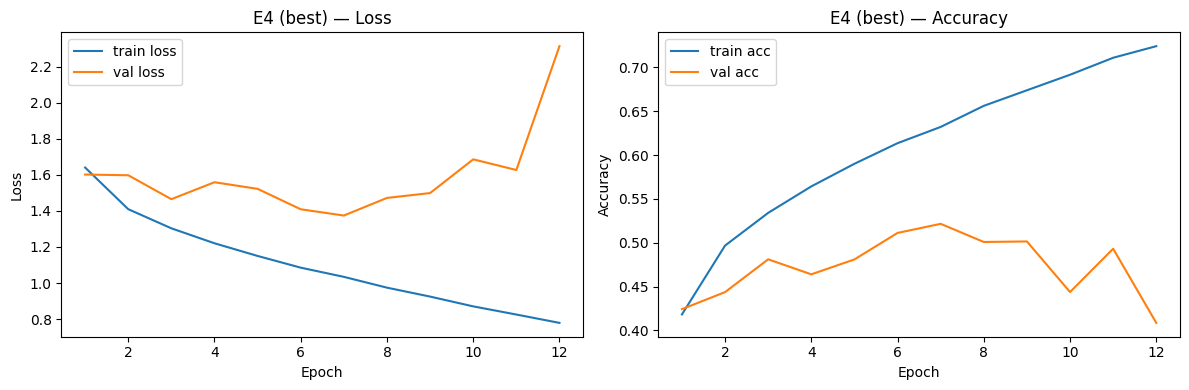

In [ ]:
# Figure: curves for best run (E4)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes
epochs = range(1, len(best_run_history["train_loss"]) + 1)
ax1.plot(epochs, best_run_history["train_loss"], label="train loss")
ax1.plot(epochs, best_run_history["val_loss"], label="val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("E4 (best) — Loss")
ax2.plot(epochs, best_run_history["train_acc"], label="train acc")
ax2.plot(epochs, best_run_history["val_acc"], label="val acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.set_title("E4 (best) — Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_best.png"), dpi=100, bbox_inches="tight")
plt.show()

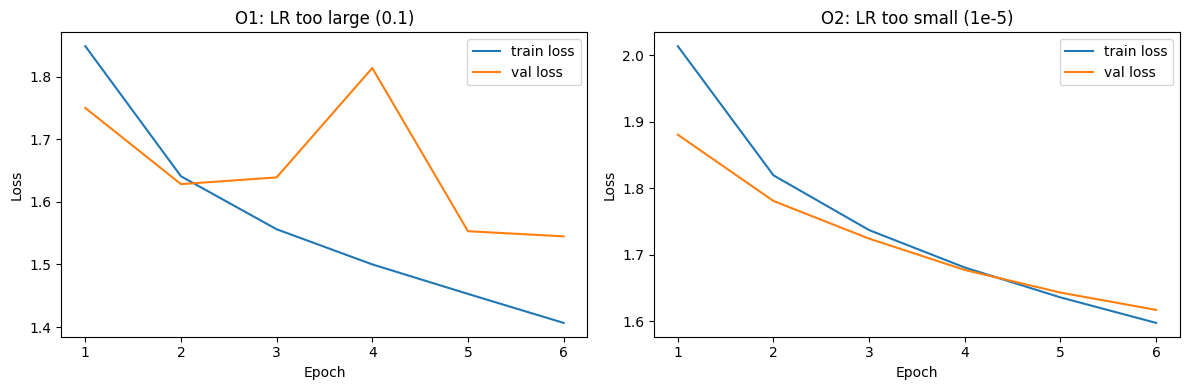

In [ ]:
# Figure: O1 (lr too large) vs O2 (lr too small)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep1 = range(1, len(hist_o1["val_loss"]) + 1)
ep2 = range(1, len(hist_o2["val_loss"]) + 1)
axes[0].plot(ep1, hist_o1["train_loss"], label="train loss")
axes[0].plot(ep1, hist_o1["val_loss"], label="val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].set_title("O1: LR too large (0.1)")
axes[1].plot(ep2, hist_o2["train_loss"], label="train loss")
axes[1].plot(ep2, hist_o2["val_loss"], label="val loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].set_title("O2: LR too small (1e-5)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"), dpi=100, bbox_inches="tight")
plt.show()

# Домашнее задание к семинарам 08-09 (HW08-09)

**Тема:** PyTorch 101 и основы оптимизации обучения.
- Часть S08: MLP и регуляризация (Dropout, BatchNorm, EarlyStopping).
- Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

**Датасет:** KMNIST (вариант A, через torchvision).

## 2.3.1. Импорты, seed и устройство

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from datetime import datetime

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs("artifacts/figures", exist_ok=True)

Device: cpu


## 2.3.2. Данные и DataLoader

In [ ]:
DATASET_NAME = "CIFAR10"
BATCH_SIZE = 128
VAL_RATIO = 0.2

transform = transforms.Compose([transforms.ToTensor()])

train_full = torchvision.datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

n_val = int(len(train_full) * VAL_RATIO)
n_train = len(train_full) - n_val
train_dataset, val_dataset = random_split(train_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

RuntimeError: Error downloading train-images-idx3-ubyte.gz:
Tried http://codh.rois.ac.jp/kmnist/dataset/kmnist/, got:
<urlopen error [WinError 10060] Попытка установить соединение была безуспешной, т.к. от другого компьютера за требуемое время не получен нужный отклик, или было разорвано уже установленное соединение из-за неверного отклика уже подключенного компьютера>


In [ ]:
# Sanity-check: размеры батча, shapes, диапазоны значений
x, y = next(iter(train_loader))
print(f"Batch size: {x.shape[0]}")
print(f"x.shape: {x.shape}, y.shape: {y.shape}")
print(f"x range: [{x.min():.3f}, {x.max():.3f}]")

## 2.3.3. Модель MLP и цикл обучения

In [ ]:
def get_flat_size(dataset):
    x, _ = dataset[0]
    return x.numel()

INPUT_SIZE = get_flat_size(train_dataset)
NUM_CLASSES = 10

class MLP(nn.Module):
    def __init__(self, hidden_sizes=(256, 128), dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev = INPUT_SIZE
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU(inplace=True))
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, NUM_CLASSES)

    def forward(self, x):
        x = self.flatten(x)
        x = self.backbone(x)
        return self.head(x)  # logits

def model_summary_str(hidden_sizes, dropout_p, use_batchnorm):
    parts = [f"hidden={hidden_sizes}", "ReLU"]
    if dropout_p > 0:
        parts.append(f"Dropout(p={dropout_p})")
    if use_batchnorm:
        parts.append("BatchNorm")
    return "; ".join(parts)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

## Часть A (S08): регуляризация — E1 (base), E2 (Dropout), E3 (BatchNorm)

In [ ]:
HIDDEN_SIZES = (256, 128)
MAX_EPOCHS_A = 15
LR_BASE = 1e-3
criterion = nn.CrossEntropyLoss()
run_history = {}

In [ ]:
def run_experiment(exp_id, model, optimizer, max_epochs, run_history_key):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(max_epochs):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if (epoch + 1) % 3 == 0:
            print(f"  {exp_id} epoch {epoch+1}: val_acc={va:.4f}, val_loss={vl:.4f}")
    run_history[run_history_key] = history
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    return best_val_acc, best_val_loss, history

In [ ]:
print("E1 (base): MLP без Dropout/BatchNorm")
model_e1 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.0, use_batchnorm=False).to(device)
opt_e1 = torch.optim.Adam(model_e1.parameters(), lr=LR_BASE)
e1_acc, e1_loss, _ = run_experiment("E1", model_e1, opt_e1, MAX_EPOCHS_A, "E1")

In [ ]:
print("E2 (Dropout): как E1 + Dropout(p=0.3)")
model_e2 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.3, use_batchnorm=False).to(device)
opt_e2 = torch.optim.Adam(model_e2.parameters(), lr=LR_BASE)
e2_acc, e2_loss, _ = run_experiment("E2", model_e2, opt_e2, MAX_EPOCHS_A, "E2")

In [ ]:
print("E3 (BatchNorm): как E1 + BatchNorm")
model_e3 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.0, use_batchnorm=True).to(device)
opt_e3 = torch.optim.Adam(model_e3.parameters(), lr=LR_BASE)
e3_acc, e3_loss, _ = run_experiment("E3", model_e3, opt_e3, MAX_EPOCHS_A, "E3")

In [ ]:
best_ab = "E2" if e2_acc >= e3_acc else "E3"
print(f"Лучший из E2/E3 по val_accuracy: {best_ab}")
USE_DROPOUT_E4 = best_ab == "E2"
USE_BN_E4 = best_ab == "E3"
DROPOUT_P_E4 = 0.3 if USE_DROPOUT_E4 else 0.0

## E4: лучший из (E2/E3) + EarlyStopping, сохранение best_model.pt

In [ ]:
PATIENCE = 4
model_e4 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=DROPOUT_P_E4, use_batchnorm=USE_BN_E4).to(device)
opt_e4 = torch.optim.Adam(model_e4.parameters(), lr=LR_BASE)

best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
history_e4 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(MAX_EPOCHS_A):
    tl, ta = train_one_epoch(model_e4, train_loader, criterion, opt_e4, device)
    vl, va = evaluate(model_e4, val_loader, criterion, device)
    history_e4["train_loss"].append(tl)
    history_e4["train_acc"].append(ta)
    history_e4["val_loss"].append(vl)
    history_e4["val_acc"].append(va)
    if va > best_val_acc:
        best_val_acc = va
        best_val_loss = vl
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
    else:
        patience_counter += 1
    if (epoch + 1) % 3 == 0:
        print(f"E4 epoch {epoch+1}: val_acc={va:.4f}, best={best_val_acc:.4f} @ epoch {best_epoch}")
    if patience_counter >= PATIENCE:
        print(f"EarlyStopping at epoch {epoch+1}")
        break

run_history["E4"] = history_e4
epochs_e4 = len(history_e4["val_acc"])

## Часть B (S09): O1 (LR большой), O2 (LR маленький), O3 (SGD+momentum + weight decay)

In [ ]:
EPOCHS_LR = 7
EPOCHS_O3 = 12

print("O1: Adam, lr=0.1 (слишком большой)")
model_o1 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=DROPOUT_P_E4, use_batchnorm=USE_BN_E4).to(device)
opt_o1 = torch.optim.Adam(model_o1.parameters(), lr=0.1)
o1_acc, o1_loss, h_o1 = run_experiment("O1", model_o1, opt_o1, EPOCHS_LR, "O1")

print("O2: Adam, lr=1e-5 (слишком маленький)")
model_o2 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=DROPOUT_P_E4, use_batchnorm=USE_BN_E4).to(device)
opt_o2 = torch.optim.Adam(model_o2.parameters(), lr=1e-5)
o2_acc, o2_loss, h_o2 = run_experiment("O2", model_o2, opt_o2, EPOCHS_LR, "O2")

In [ ]:
print("O3: SGD+momentum + weight_decay")
model_o3 = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=DROPOUT_P_E4, use_batchnorm=USE_BN_E4).to(device)
opt_o3 = torch.optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
o3_acc, o3_loss, h_o3 = run_experiment("O3", model_o3, opt_o3, EPOCHS_O3, "O3")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1, ax2 = axes
ep = range(1, len(h_o1["val_loss"]) + 1)
ax1.plot(ep, h_o1["val_loss"], label="O1 val_loss (lr=0.1)", color="C0")
ax1.plot(ep, h_o1["val_acc"], label="O1 val_acc", color="C0", linestyle="--")
ax1.set_title("O1: LR слишком большой")
ax1.legend()
ax1.set_xlabel("epoch")
ep2 = range(1, len(h_o2["val_loss"]) + 1)
ax2.plot(ep2, h_o2["val_loss"], label="O2 val_loss (lr=1e-5)", color="C1")
ax2.plot(ep2, h_o2["val_acc"], label="O2 val_acc", color="C1", linestyle="--")
ax2.set_title("O2: LR слишком маленький")
ax2.legend()
ax2.set_xlabel("epoch")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=120)
plt.show()

## Артефакты: runs.csv, best_config.json, curves_best.png

In [ ]:
def get_best_metrics(history):
    return max(history["val_acc"]), min(history["val_loss"])

rows = [
    {"experiment_id": "E1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, 0.0, False),
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": MAX_EPOCHS_A, "best_val_accuracy": e1_acc, "best_val_loss": e1_loss},
    {"experiment_id": "E2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, 0.3, False),
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": MAX_EPOCHS_A, "best_val_accuracy": e2_acc, "best_val_loss": e2_loss},
    {"experiment_id": "E3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, 0.0, True),
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": MAX_EPOCHS_A, "best_val_accuracy": e3_acc, "best_val_loss": e3_loss},
    {"experiment_id": "E4", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, DROPOUT_P_E4, USE_BN_E4) + "; EarlyStopping",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": epochs_e4, "best_val_accuracy": best_val_acc, "best_val_loss": best_val_loss},
    {"experiment_id": "O1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, DROPOUT_P_E4, USE_BN_E4),
     "optimizer": "Adam", "lr": 0.1, "momentum": 0, "weight_decay": 0,
     "epochs_trained": EPOCHS_LR, "best_val_accuracy": o1_acc, "best_val_loss": o1_loss},
    {"experiment_id": "O2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, DROPOUT_P_E4, USE_BN_E4),
     "optimizer": "Adam", "lr": 1e-5, "momentum": 0, "weight_decay": 0,
     "epochs_trained": EPOCHS_LR, "best_val_accuracy": o2_acc, "best_val_loss": o2_loss},
    {"experiment_id": "O3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary_str(HIDDEN_SIZES, DROPOUT_P_E4, USE_BN_E4),
     "optimizer": "SGD", "lr": 0.01, "momentum": 0.9, "weight_decay": 1e-4,
     "epochs_trained": EPOCHS_O3, "best_val_accuracy": o3_acc, "best_val_loss": o3_loss},
]

import csv
with open("artifacts/runs.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)
print("Saved artifacts/runs.csv")

In [ ]:
best_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "hidden_sizes": list(HIDDEN_SIZES),
    "dropout_p": DROPOUT_P_E4,
    "use_batchnorm": USE_BN_E4,
    "optimizer": "Adam",
    "lr": LR_BASE,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_acc,
    "early_stopping_patience": PATIENCE,
    "timestamp": datetime.now().isoformat(),
}
with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2)
print("Saved artifacts/best_config.json")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ep = range(1, len(history_e4["train_loss"]) + 1)
axes[0].plot(ep, history_e4["train_loss"], label="train_loss")
axes[0].plot(ep, history_e4["val_loss"], label="val_loss")
axes[0].set_title("E4 (best run): Loss")
axes[0].legend()
axes[0].set_xlabel("epoch")
axes[1].plot(ep, history_e4["train_acc"], label="train_acc")
axes[1].plot(ep, history_e4["val_acc"], label="val_acc")
axes[1].set_title("E4 (best run): Accuracy")
axes[1].legend()
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png", dpi=120)
plt.show()

## Финальная оценка лучшей модели на test (один раз)

In [ ]:
best_model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=DROPOUT_P_E4, use_batchnorm=USE_BN_E4).to(device)
best_model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Final test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")